In [1]:
from temgym_core.components import Detector
from temgym_core.utils import wavelength2energy
from temgym_core.gaussian_action2D import (make_gaussian, run_to_end)
import jax.numpy as jnp
import numpy as np
from temgym_core.evaluate import evaluate_gaussians_for
from temgym_core.utils import zero_phase, make_aperture, FresnelPropagator
import matplotlib.pyplot as plt
import jax
jax.config.update("jax_enable_x64", True)

%matplotlib widget

In [2]:
def _detector_mesh(detector: Detector) -> tuple[np.ndarray, np.ndarray]:
    det_edge_x, det_edge_y = detector.coords_1d
    det_edge_x = np.asarray(det_edge_x)
    det_edge_y = np.asarray(det_edge_y)
    Y, X = np.meshgrid(det_edge_y, det_edge_x, indexing="ij")
    return Y, X

def _window_size(detector: Detector) -> float:
    width_x = float(detector.pixel_size[1]) * detector.shape[1]
    return width_x


In [3]:
propagation_distance = 0.001
pixel_size = (0.0005, 0.0005)
wavelength = 0.00001
wo = 0.1
shape = (2000, 2000)

voltage = wavelength2energy(wavelength)

input_grid = Detector(z=0.0, pixel_size=pixel_size, shape=shape)
detector = Detector(z=propagation_distance, pixel_size=pixel_size, shape=shape)

gaussian = make_gaussian(
    x=0.0,
    y=0.0,
    dx=0.0,
    dy=0.0,
    z=0.0,
    voltage=voltage,
    waist_x=wo,
    waist_y=wo,
    InitAmp=1.0,
    InitPhase=0.0,
    RadiusOfCurvature_x=jnp.inf,
    RadiusOfCurvature_y=jnp.inf,
)

propagated = run_to_end(gaussian, (detector,))
analytic_gauss_image = evaluate_gaussians_for(propagated, detector)

gauss_input = evaluate_gaussians_for(gaussian, input_grid)
gauss_input = zero_phase(
    gauss_input,
    gauss_input.shape[0] // 2,
    gauss_input.shape[1] // 2,
)

Y, X = _detector_mesh(detector)
fresnel_gauss_image = FresnelPropagator(
    gauss_input,
    _window_size(detector),
    wavelength,
    propagation_distance,
)
analytic_gauss_image = np.array(analytic_gauss_image)
fresnel_gauss_image = np.array(fresnel_gauss_image)

analytic_gauss_image /= np.max(np.abs(analytic_gauss_image))
fresnel_gauss_image /= np.max(np.abs(fresnel_gauss_image))

det_circular_mask = make_aperture(X, Y, aperture_ratio=0.4)

analytic_gauss_image *= det_circular_mask
fresnel_gauss_image *= det_circular_mask

analytic_gauss_image = np.where(
    det_circular_mask,
    analytic_gauss_image,
    np.abs(analytic_gauss_image),
)
fresnel_gauss_image = np.where(
    det_circular_mask,
    fresnel_gauss_image,
    np.abs(fresnel_gauss_image),
)


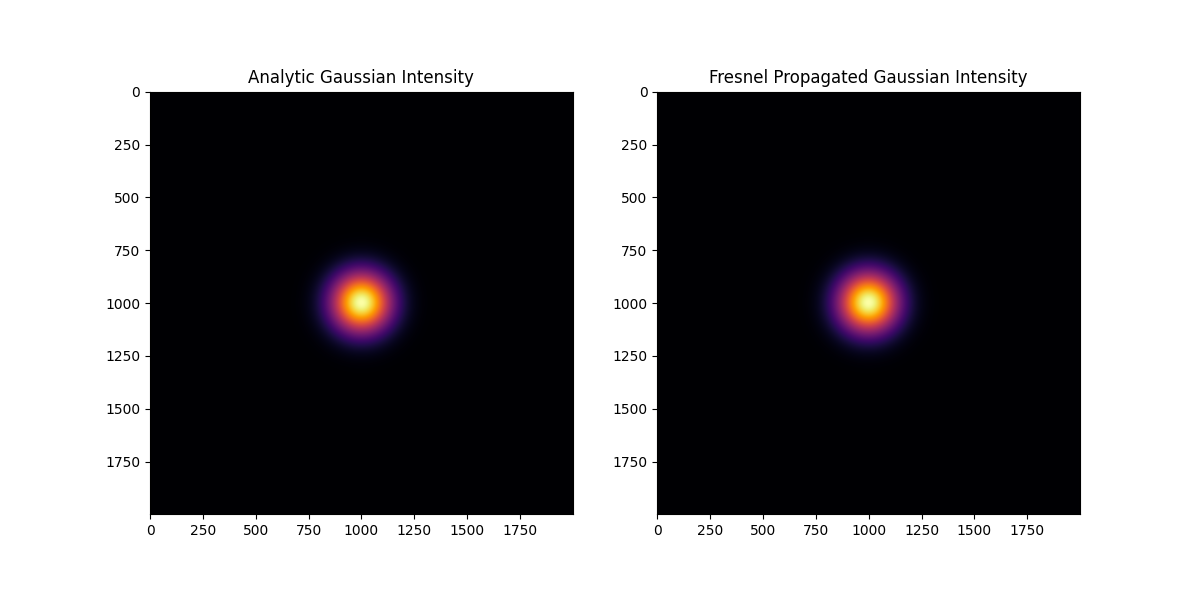

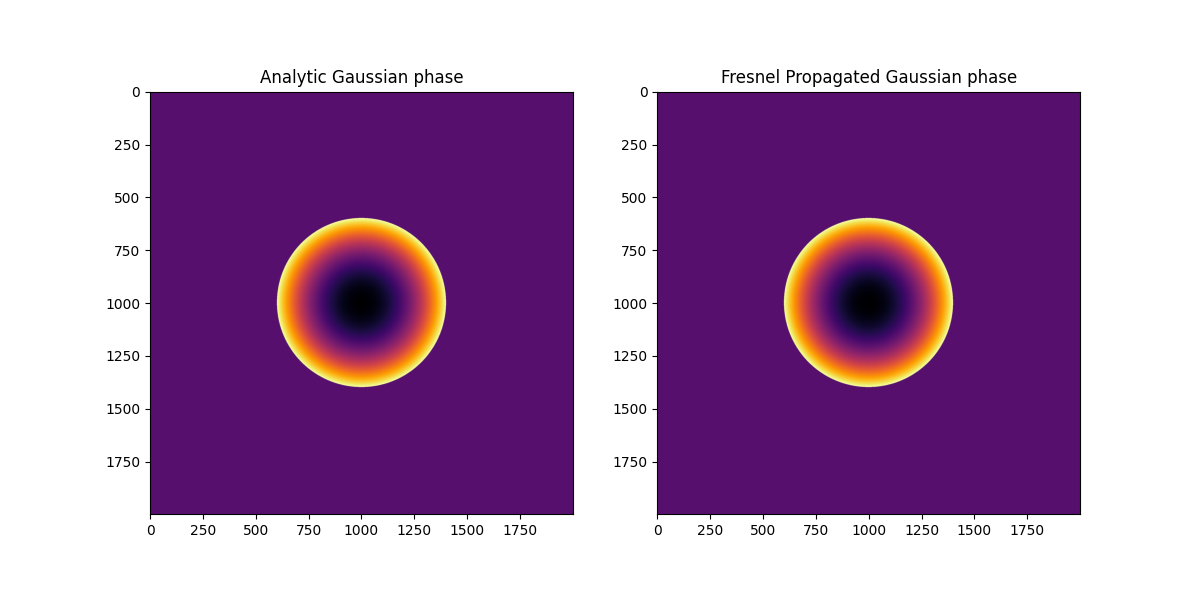

: 

In [ ]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Analytic Gaussian Intensity")
plt.imshow(np.abs(analytic_gauss_image) ** 2, cmap="inferno")
plt.subplot(1, 2, 2)
plt.title("Fresnel Propagated Gaussian Intensity")
plt.imshow(np.abs(fresnel_gauss_image) ** 2, cmap="inferno")
plt.show()

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Analytic Gaussian phase")
plt.imshow(np.angle(analytic_gauss_image), cmap="inferno")
plt.subplot(1, 2, 2)
plt.title("Fresnel Propagated Gaussian phase")
plt.imshow(np.angle(fresnel_gauss_image), cmap="inferno")
plt.show()